### short term memory

In [12]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver # checkpointer to implement persistance in code

In [13]:
load_dotenv()

True

In [14]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [15]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [16]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [17]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [18]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

# to implement persistance
checkpointer = InMemorySaver()

# checkpointer is passed to the graph during compile time
workflow = graph.compile(checkpointer=checkpointer)

In [19]:
# thread id is passed to store that whole conversation
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explanation': 'This joke is a play on words, using a common adjective "crusty" in a double meaning. \n\nIn one sense, "crusty" can describe the outer layer of a pizza, which is typically crunchy and golden brown. However, "crusty" can also be used to describe someone\'s mood or personality, implying that they are irritable, grumpy, or unpleasant.\n\nThe joke relies on this pun, setting up the expectation that the pizza is in a bad mood for some reason, and then subverting it with a clever wordplay. By saying the pizza is "feeling a little crusty," the joke is making a humorous connection between the pizza\'s literal crust and its emotional state, creating a lighthearted and amusing effect.'}

In [20]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a common adjective "crusty" in a double meaning. \n\nIn one sense, "crusty" can describe the outer layer of a pizza, which is typically crunchy and golden brown. However, "crusty" can also be used to describe someone\'s mood or personality, implying that they are irritable, grumpy, or unpleasant.\n\nThe joke relies on this pun, setting up the expectation that the pizza is in a bad mood for some reason, and then subverting it with a clever wordplay. By saying the pizza is "feeling a little crusty," the joke is making a humorous connection between the pizza\'s literal crust and its emotional state, creating a lighthearted and amusing effect.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f166665-c192-6724-8002-fe5c3b081c3b'}}, metadata={'source': 'loop', 'step': 2,

In [21]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a common adjective "crusty" in a double meaning. \n\nIn one sense, "crusty" can describe the outer layer of a pizza, which is typically crunchy and golden brown. However, "crusty" can also be used to describe someone\'s mood or personality, implying that they are irritable, grumpy, or unpleasant.\n\nThe joke relies on this pun, setting up the expectation that the pizza is in a bad mood for some reason, and then subverting it with a clever wordplay. By saying the pizza is "feeling a little crusty," the joke is making a humorous connection between the pizza\'s literal crust and its emotional state, creating a lighthearted and amusing effect.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f166665-c192-6724-8002-fe5c3b081c3b'}}, metadata={'source': 'loop', 'step': 2

In [22]:
# different thread id
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.',
 'explanation': 'This joke is a play on words, using a common phrase associated with romantic relationships and giving it a literal twist. The phrase "tangled up in a relationship" typically means to become deeply involved or entangled in the complexities and emotions of a romantic partnership. However, in this joke, the word "tangled" is used to reference the physical properties of spaghetti, which is a long, thin, and flexible noodle that can easily become knotted or tangled.\n\nThe humor comes from the double meaning of the phrase, as the spaghetti is literally afraid of getting tangled up (as in, physically knotted) because of its physical properties, but the phrase is also a common idiomatic expression used to describe the complexities of romantic relationships. The joke relies on this wordplay to create a pun, which is a type of humorous de

In [23]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'explanation': 'This joke is a play on words, using a common phrase associated with romantic relationships and giving it a literal twist. The phrase "tangled up in a relationship" typically means to become deeply involved or entangled in the complexities and emotions of a romantic partnership. However, in this joke, the word "tangled" is used to reference the physical properties of spaghetti, which is a long, thin, and flexible noodle that can easily become knotted or tangled.\n\nThe humor comes from the double meaning of the phrase, as the spaghetti is literally afraid of getting tangled up (as in, physically knotted) because of its physical properties, but the phrase is also a common idiomatic expression used to describe the complexities of romantic relationships. The joke relies on this wordplay to create a pun, which is a 

In [24]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a common adjective "crusty" in a double meaning. \n\nIn one sense, "crusty" can describe the outer layer of a pizza, which is typically crunchy and golden brown. However, "crusty" can also be used to describe someone\'s mood or personality, implying that they are irritable, grumpy, or unpleasant.\n\nThe joke relies on this pun, setting up the expectation that the pizza is in a bad mood for some reason, and then subverting it with a clever wordplay. By saying the pizza is "feeling a little crusty," the joke is making a humorous connection between the pizza\'s literal crust and its emotional state, creating a lighthearted and amusing effect.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f166665-c192-6724-8002-fe5c3b081c3b'}}, metadata={'source': 'loop', 'step': 2,

In [25]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a common adjective "crusty" in a double meaning. \n\nIn one sense, "crusty" can describe the outer layer of a pizza, which is typically crunchy and golden brown. However, "crusty" can also be used to describe someone\'s mood or personality, implying that they are irritable, grumpy, or unpleasant.\n\nThe joke relies on this pun, setting up the expectation that the pizza is in a bad mood for some reason, and then subverting it with a clever wordplay. By saying the pizza is "feeling a little crusty," the joke is making a humorous connection between the pizza\'s literal crust and its emotional state, creating a lighthearted and amusing effect.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f166665-c192-6724-8002-fe5c3b081c3b'}}, metadata={'source': 'loop', 'step': 2

In [26]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'explanation': 'This joke is a play on words, using a common phrase associated with romantic relationships and giving it a literal twist. The phrase "tangled up in a relationship" typically means to become deeply involved or entangled in the complexities and emotions of a romantic partnership. However, in this joke, the word "tangled" is used to reference the physical properties of spaghetti, which is a long, thin, and flexible noodle that can easily become knotted or tangled.\n\nThe humor comes from the double meaning of the phrase, as the spaghetti is literally afraid of getting tangled up (as in, physically knotted) because of its physical properties, but the phrase is also a common idiomatic expression used to describe the complexities of romantic relationships. The joke relies on this wordplay to create a pun, which is a

#### Time Travel

In [28]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f166665-b9f4-61c3-8000-075f5b097e02"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f166665-b9f4-61c3-8000-075f5b097e02'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-12T13:55:23.505709+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f166665-b9ef-6e4b-bfff-148fc12abbd6'}}, tasks=(PregelTask(id='eec5cc51-91b3-566e-92fb-88769ad9cccf', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.'}),), interrupts=())

In [29]:
# in place of topic "NONE" so execution will start from that checkpoin
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f166665-b9f4-61c3-8000-075f5b097e02"}})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explanation': 'This joke is a play on words, using a common phrase "feeling a little crusty" to create a pun. \n\nIn everyday language, "feeling crusty" is an idiomatic expression that means being irritable, grumpy, or in a bad mood. However, in the context of a pizza, "crusty" has a literal meaning as well, referring to the crunchy outer layer of the pizza, known as the crust.\n\nThe joke relies on this double meaning of "crusty" to create humor. It sets up the expectation that the pizza is in a bad mood, and then subverts it by using the word "crusty" in a way that is both a common phrase for being grumpy and a literal description of the pizza\'s crust. This wordplay creates a clever and amusing connection between the setup and the punchline, making the joke humorous and entertaining.'}

In [30]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, using a common phrase "feeling a little crusty" to create a pun. \n\nIn everyday language, "feeling crusty" is an idiomatic expression that means being irritable, grumpy, or in a bad mood. However, in the context of a pizza, "crusty" has a literal meaning as well, referring to the crunchy outer layer of the pizza, known as the crust.\n\nThe joke relies on this double meaning of "crusty" to create humor. It sets up the expectation that the pizza is in a bad mood, and then subverts it by using the word "crusty" in a way that is both a common phrase for being grumpy and a literal description of the pizza\'s crust. This wordplay creates a clever and amusing connection between the setup and the punchline, making the joke humorous and entertaining.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '

#### Updating State

In [32]:
## inplace of pizza topic is samosa
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f166665-b9f4-61c3-8000-075f5b097e02", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f166672-204d-6a7d-8001-0c9deb86d3fe'}}

In [33]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f166672-204d-6a7d-8001-0c9deb86d3fe'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-06-12T14:00:56.360409+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f166665-b9f4-61c3-8000-075f5b097e02'}}, tasks=(PregelTask(id='b91eb7b9-ca6a-9658-02a4-a682bbbcd0ab', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f166670-ddfa-671f-8001-471340e1d696'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-06-12T14:00:22.562179+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id

In [35]:
# in place of topic "NONE" so execution will start from that checkpoin
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f166670-ddfa-671f-8001-471340e1d696"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crusty" and had a lot of "filling" emotional issues to work through.',
 'explanation': 'This joke is a play on words, using the characteristics of a samosa to create a pun. A samosa is a type of fried or baked pastry that typically has a crunchy, crusty exterior and a filling interior, often consisting of spiced potatoes, peas, and other ingredients.\n\nThe joke begins by asking why the samosa went to therapy, setting up the expectation that the punchline will be a clever explanation for the samosa\'s emotional state. The answer, "it was feeling a little \'crusty\' and had a lot of \'filling\' emotional issues to work through," uses wordplay to create a humorous connection between the samosa\'s physical characteristics and its emotional state.\n\nThe term "crusty" has a double meaning here. In one sense, it refers to the samosa\'s crunchy exterior, but it also implies that the samosa is 

In [36]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crusty" and had a lot of "filling" emotional issues to work through.', 'explanation': 'This joke is a play on words, using the characteristics of a samosa to create a pun. A samosa is a type of fried or baked pastry that typically has a crunchy, crusty exterior and a filling interior, often consisting of spiced potatoes, peas, and other ingredients.\n\nThe joke begins by asking why the samosa went to therapy, setting up the expectation that the punchline will be a clever explanation for the samosa\'s emotional state. The answer, "it was feeling a little \'crusty\' and had a lot of \'filling\' emotional issues to work through," uses wordplay to create a humorous connection between the samosa\'s physical characteristics and its emotional state.\n\nThe term "crusty" has a double meaning here. In one sense, it refers to the samosa\'s crunchy exterior, but it also implies

#### Fault Tolerance

In [1]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [2]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [3]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(30)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [4]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

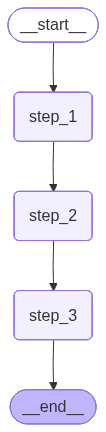

In [5]:
graph

In [6]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [7]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f166658-2d3b-6a97-8001-6f52a8799421'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-12T13:49:19.784002+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f166658-2d36-603b-8000-3be88297df88'}}, tasks=(PregelTask(id='e3155080-0c00-4b32-7ef1-98a42143f526', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [8]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f166658-2d3b-6a97-8001-6f52a8799421'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-12T13:49:19.784002+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f166658-2d36-603b-8000-3be88297df88'}}, tasks=(PregelTask(id='e3155080-0c00-4b32-7ef1-98a42143f526', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f166658-2d36-603b-8000-3be88297df88'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-12T13:49:19.781689+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'ch

In [9]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}


In [10]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f16665a-cf16-688b-8003-bb710981fc1c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-06-12T13:50:30.442817+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f16665a-cf11-694c-8002-5fe9f681772b'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f16665a-cf11-694c-8002-5fe9f681772b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-12T13:50:30.440788+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f166658-2d3b-6a97-8001-6f52a8799421'}}, tasks=(PregelTask(id='4f5cca10-fd85-5a1a-a804-f3227fe7134

#### Time Travel

NameError: name 'workflow' is not defined